<a href="https://colab.research.google.com/github/he380801-sketch/eeg-classification-ml-comparison/blob/main/vecinosd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from scipy import stats
import warnings
import os

In [ ]:
file_id = '1k2BqAKd_bqT_eV-TB5isdfiDnJbYXVwo'
url = f'https://drive.google.com/uc?id={file_id}'

# Si tu archivo es un CSV:
try:
    df = pd.read_csv(url)
    print("¡Base de datos CSV cargada exitosamente!")
    print(df.head())
except Exception as e:
    print(f"Error al cargar la base de datos CSV: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================
# VERIFICACIÓN Y EXPLORACIÓN INICIAL
# ============================================

print("\n" + "="*50)
print("📋 INFORMACIÓN DEL DATASET")
print("="*50)

print(f"\nPrimeras 5 filas:")
print(df.head())

print(f"\nColumnas: {df.columns.tolist()}")
print(f"Grupos únicos: {df['Grupo'].unique()}")
print(f"Participantes: {df['Participante'].unique()}")
print(f"Rango de minutos: {df['Minuto'].min()} - {df['Minuto'].max()}")

# Verificar valores nulos
nulos = df.isnull().sum()
if nulos.sum() > 0:
    print(f"\n⚠️ Valores nulos encontrados:")
    print(nulos[nulos > 0])
else:
    print(f"\n✅ No hay valores nulos en el dataset")


📋 INFORMACIÓN DEL DATASET

Primeras 5 filas:
   Grupo Participante  Minuto        C3        C4        CZ       EMG  \
0      0          EMV       1  1.457191  1.465362  1.389850  1.469966   
1      0          EMV      10  1.442564  1.372664  1.361794  1.310307   
2      0          EMV      11  1.445738  1.397893  1.363018  1.246467   
3      0          EMV      12  1.381500  1.422462  1.443394  1.445102   
4      0          EMV      13  1.443665  1.355041  1.360214  1.301061   

         F3        F4        F7  ...        O1        O2        P3        P4  \
0  1.471585  1.383370  1.416681  ...  1.419505  1.460171  1.435626  1.401177   
1  1.477391  1.366440  1.439025  ...  1.417780  1.421081  1.410483  1.395753   
2  1.451693  1.372738  1.398308  ...  1.444138  1.434578  1.425999  1.411785   
3  1.422085  1.413301  1.450779  ...  1.427840  1.451817  1.403597  1.434047   
4  1.474152  1.365256  1.433039  ...  1.415445  1.402281  1.391482  1.395755   

         PZ       ROG        T3   

In [ ]:
# ============================================
# LIMPIEZA Y PREPARACIÓN DE DATOS
# ============================================

print("\n" + "="*50)
print("🧹 LIMPIEZA Y PREPARACIÓN")
print("="*50)

# Reemplazar NaN con la media de la columna
df_clean = df.fillna(df.mean(numeric_only=True))

# Identificar columnas de electrodos (excluyendo Grupo, Participante, Minuto)
columnas_a_excluir = ['Grupo', 'Participante', 'Minuto']
electrode_cols = [col for col in df_clean.columns if col not in columnas_a_excluir]

print(f"✓ {len(electrode_cols)} electrodos/features identificados")

# Crear variable objetivo
X = df_clean[electrode_cols]
y = df_clean['Grupo']

print(f"\nFeatures (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Distribución de clases:\n{y.value_counts()}")


🧹 LIMPIEZA Y PREPARACIÓN
✓ 22 electrodos/features identificados

Features (X): (900, 22)
Target (y): (900,)
Distribución de clases:
Grupo
0    500
1    400
Name: count, dtype: int64


In [ ]:
# ============================================
# DIVISIÓN DE DATOS
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Train set: (720, 22)
Test set: (180, 22)


In [ ]:
# ============================================
# EVALUACIÓN DEL MODELO
# ============================================

print("\n" + "="*50)
print("📊 EVALUACIÓN DEL MODELO")
print("="*50)

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)

print(f"\nAccuracy en test: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


📊 EVALUACIÓN DEL MODELO

Accuracy en test: 0.9333

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       100
           1       0.93      0.93      0.93        80

    accuracy                           0.93       180
   macro avg       0.93      0.93      0.93       180
weighted avg       0.93      0.93      0.93       180




📈 GENERANDO VISUALIZACIONES


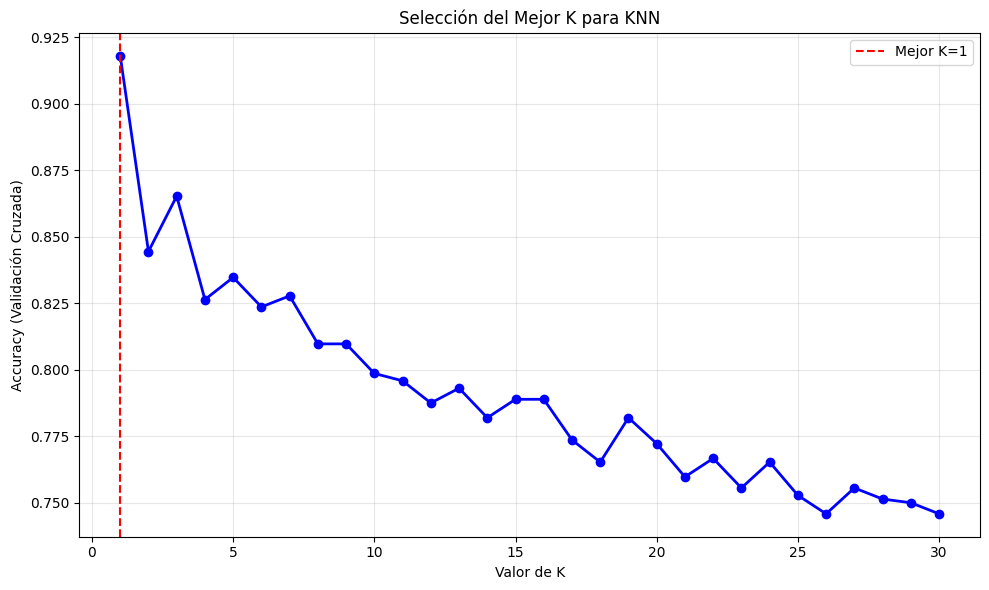

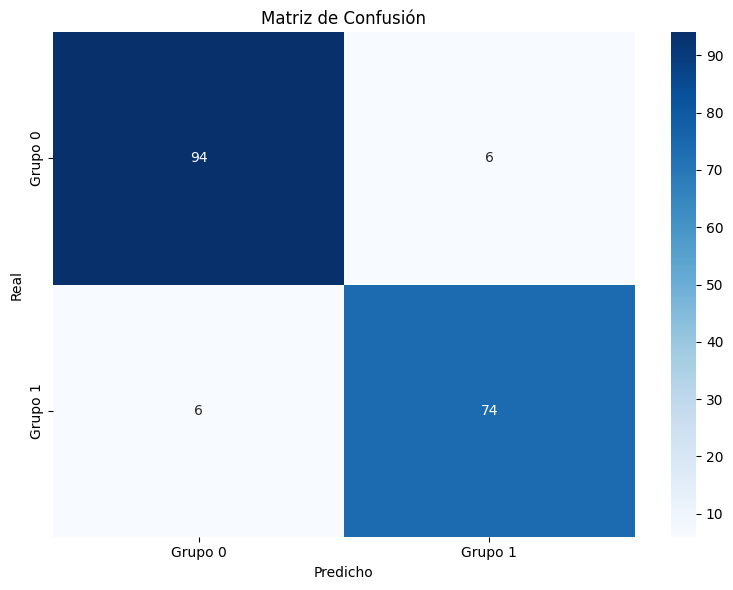

In [ ]:
# ============================================
# VISUALIZACIONES
# ============================================

print("\n" + "="*50)
print("📈 GENERANDO VISUALIZACIONES")
print("="*50)

# Figura 1: Selección de K
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores, marker='o', color='blue', linewidth=2)
plt.xlabel('Valor de K')
plt.ylabel('Accuracy (Validación Cruzada)')
plt.title('Selección del Mejor K para KNN')
plt.grid(True, alpha=0.3)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Mejor K={best_k}')
plt.legend()
plt.tight_layout()
plt.savefig('seleccion_k.png', dpi=150)
plt.show()

# Figura 2: Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Grupo 0', 'Grupo 1'],
            yticklabels=['Grupo 0', 'Grupo 1'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150)
plt.show()

In [ ]:
# ============================================
# ENCONTRAR EL MEJOR VALOR DE K
# ============================================

print("\n" + "="*50)
print("🔍 BÚSQUEDA DEL MEJOR K")
print("="*50)

# Definir rango de K a probar
k_range = range(1, 31)
k_scores = []

# Validación cruzada para cada K
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

# Encontrar el mejor K
best_k = k_range[np.argmax(k_scores)]
print(f"✅ Mejor valor de K encontrado: {best_k}")
print(f"   Accuracy promedio (validación cruzada): {max(k_scores):.4f}")

# Entrenar modelo con el mejor K
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)



🔍 BÚSQUEDA DEL MEJOR K
✅ Mejor valor de K encontrado: 1
   Accuracy promedio (validación cruzada): 0.9181


KNeighborsClassifier(n_neighbors=1)

In [ ]:
# 1. Verifica si hay DATA LEAKAGE (fuga de información)
# ¿Los mismos participantes están en train y test?
participantes_train = df.loc[X_train.index, 'Participante'].unique()
participantes_test = df.loc[X_test.index, 'Participante'].unique()
participantes_comunes = set(participantes_train) & set(participantes_test)
print(f"Participantes en común: {participantes_comunes}")
# 👆 Si hay participantes repetidos, ¡es PROBLEMA GRAVE!

# 2. Revisa la matriz de confusión
print(confusion_matrix(y_test, y_pred))
# Si una clase tiene muchos más aciertos que la otra, puede ser desbalance

# 3. Compara train vs test accuracy
y_train_pred = best_knn.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Diferencia: {train_acc - test_acc:.4f}")
# 👆 Si train >> test (ej: 99% vs 91%), hay SOBREAJUSTE

Participantes en común: {'AEF', 'GUR', 'GH2', 'EMV', 'RAN', 'RLM', 'JAN', 'MJN', 'FGV', 'LIV', 'JAL', 'CLM', 'VCN', 'JGM', 'RRM', 'PCM', 'MGN', 'MMA'}
[[94  6]
 [ 6 74]]
Train accuracy: 1.0000
Test accuracy: 0.9333
Diferencia: 0.0667


In [ ]:
# 1. Verifica si hay DATA LEAKAGE (fuga de información)
# ¿Los mismos participantes están en train y test?
participantes_train = df.loc[X_train.index, 'Participante'].unique()
participantes_test = df.loc[X_test.index, 'Participante'].unique()
participantes_comunes = set(participantes_train) & set(participantes_test)
print(f"Participantes en común: {participantes_comunes}")
# 👆 Si hay participantes repetidos, ¡es PROBLEMA GRAVE!

# 2. Revisa la matriz de confusión
print(confusion_matrix(y_test, y_pred))
# Si una clase tiene muchos más aciertos que la otra, puede ser desbalance

# 3. Compara train vs test accuracy
y_train_pred = best_knn.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Diferencia: {train_acc - test_acc:.4f}")
# 👆 Si train >> test (ej: 99% vs 91%), hay SOBREAJUSTE

Participantes en común: {'AEF', 'GUR', 'GH2', 'EMV', 'RAN', 'RLM', 'JAN', 'MJN', 'FGV', 'LIV', 'JAL', 'CLM', 'VCN', 'JGM', 'RRM', 'PCM', 'MGN', 'MMA'}
[[94  6]
 [ 6 74]]
Train accuracy: 1.0000
Test accuracy: 0.9333
Diferencia: 0.0667


In [ ]:
# 1. Verifica si hay DATA LEAKAGE (fuga de información)
# ¿Los mismos participantes están en train y test?
participantes_train = df.loc[X_train.index, 'Participante'].unique()
participantes_test = df.loc[X_test.index, 'Participante'].unique()
participantes_comunes = set(participantes_train) & set(participantes_test)
print(f"Participantes en común: {participantes_comunes}")
# 👆 Si hay participantes repetidos, ¡es PROBLEMA GRAVE!

# 2. Revisa la matriz de confusión
print(confusion_matrix(y_test, y_pred))
# Si una clase tiene muchos más aciertos que la otra, puede ser desbalance

# 3. Compara train vs test accuracy
y_train_pred = best_knn.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Diferencia: {train_acc - test_acc:.4f}")
# 👆 Si train >> test (ej: 99% vs 91%), hay SOBREAJUSTE

Participantes en común: {'AEF', 'GUR', 'GH2', 'EMV', 'RAN', 'RLM', 'JAN', 'MJN', 'FGV', 'LIV', 'JAL', 'CLM', 'VCN', 'JGM', 'RRM', 'PCM', 'MGN', 'MMA'}
[[94  6]
 [ 6 74]]
Train accuracy: 1.0000
Test accuracy: 0.9333
Diferencia: 0.0667
